[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RadimKozl/JLNN/blob/main/examples/JLNN_pointcloud_classification.ipynb)

# **JLNN + 3D Point Clouds: Geometric Reasoning on Top of ModelNet10 with Grain pipeline**

This tutorial demonstrates how to connect raw 3D data (point clouds) with interpretable symbolic logic using the **JLNN (JAX Logical Neural Networks)** framework.

## ***1. Introduction and Theory***
-------------------------------------

Traditional deep learning models for 3D data (like PointNet) act as "black boxes". JLNN allows us to bring human logic into object classification.

### ***The principle of "Geometric grounding" (Grounding)***

Instead of pouring point coordinates directly into the network, we extract **geometric predicates** from them:
- **HasHorizontalPlane:** Are there any surfaces parallel to the ground in the object? (Seat, tabletop)
- **HasVerticalSupport:** Does the object have vertical elements? (Legs, backrest)
- **HasLegs:** Do we detect separate supports using clustering (DBSCAN)?

#### ***Interval logic $[L, U]$***

We map each geometric feature to a truth interval. For example, if the algorithm finds 4 clusters of points near the ground, it sets `HasLegs` to `[0.9, 1.0]`. If only one, it sets it to `[0.1, 0.2]`.

### ***2. INSTALLATION AND ENVIRONMENT CONFIGURATION***

In [ ]:
try:
    import jlnn
    import jraph
    import numpyro
    import optax
    import trimesh
    from flax import nnx
    import jax.numpy as jnp
    import networkx as nx
    import numpy as np
    import xarray as xr
    import pandas as pd
    import open3d as o3d
    import grain.python as grain
    import optuna
    import matplotlib.pyplot as plt
    import sklearn
    print("✅ JLNN and JAX are ready.")
except ImportError:
    print("🚀 Installing JLNN from GitHub and fixing JAX for Colab...")
    # Instalace frameworku
    #!pip install jax-lnn --quiet
    !pip install git+https://github.com/RadimKozl/JLNN.git --quiet
    !pip install optuna optuna-dashboard pandas scikit-learn matplotlib --quiet
    !pip install arviz --quiet
    !pip install seaborn --quiet
    !pip install numpyro jraph --quiet
    !pip install grain --quiet
    !pip install open3d --quiet
    !pip install networkx --quiet
    !pip install trimesh --quiet
    !pip install xarray --quiet
    !pip install kagglehub --quiet
    !pip install optax --quiet
    # Fix JAX/CUDA compatibility for 2026 in Colab
    !pip install --upgrade "jax[cuda12_pip]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html --quiet
    !pip install  scikit-learn pandas --quiet

    import os
    print("\n🔄 RESTARTING ENVIRONMENT... Please wait a second and then run the cell again.")
    os.kill(os.getpid(), 9)
    os.kill(os.getpid(), 9) # After this line, the cell stops and the environment restarts

🚀 Installing JLNN from GitHub and fixing JAX for Colab...
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.7/516.7 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.3/83.3 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.5/180.5 kB

#### ***Imports***

In [1]:
import os
import optax
import jax
import jax.numpy as jnp
from flax import nnx
import trimesh
import kagglehub
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
import grain.python as grain
from sklearn.cluster import DBSCAN
from jlnn.symbolic.compiler import LNNFormula
from jlnn.nn.functional import weighted_and

### ***3. Downloading the Modelnet10 data file***.

In [2]:
# Download latest version
path = kagglehub.dataset_download("balraj98/modelnet10-princeton-3d-object-dataset")

print("Path to dataset files:", path)

# ModelNet10 is in the 'ModelNet10' subdirectory
data_root = os.path.join(path, 'ModelNet10')

100%|██████████| 454M/454M [00:06<00:00, 75.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/balraj98/modelnet10-princeton-3d-object-dataset/versions/1


### ***4. Grain Data Pipeline***

We load .off files and convert them to normalized point clouds.

In [3]:
class ModelNet10Source(grain.RandomAccessDataSource):
    def __init__(self, root_dir, split='train'):
        self.files = []
        self.labels = []
        self.class_names = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_map = {name: i for i, name in enumerate(self.class_names)}

        for cls in self.class_names:
            cls_dir = os.path.join(root_dir, cls, split)
            if os.path.exists(cls_dir):
                for f in os.listdir(cls_dir):
                    if f.endswith('.off'):
                        self.files.append(os.path.join(cls_dir, f))
                        self.labels.append(self.class_map[cls])

    def __getitem__(self, idx):
        mesh = trimesh.load(self.files[idx])
        if isinstance(mesh, trimesh.Scene): mesh = mesh.dump(concatenate=True)
        points = mesh.sample(1024).astype(np.float32)
        # Normalization
        points -= np.mean(points, axis=0)
        points /= np.max(np.linalg.norm(points, axis=1))
        return {"points": points, "label": self.labels[idx]}

    def __len__(self): return len(self.files)

#### ***Loader initialization***

In [4]:
source = ModelNet10Source(data_root)
dataset = grain.MapDataset.source(source).shuffle(seed=42).batch(16)
data_iter = dataset.to_iter_dataset()

### ***5. Neuro-Symbolic Model (PointNet + JLNN)***

This model learns to transform geometry into truth values ​​of predicates.

In [5]:
class NSModelNet(nnx.Module):
    def __init__(self, rngs: nnx.Rngs):
        self.conv1 = nnx.Linear(3, 64, rngs=rngs)
        self.conv2 = nnx.Linear(64, 128, rngs=rngs)
        # 8 predicates (more than before – covers all classes)
        self.to_predicates = nnx.Linear(128, 8, rngs=rngs)

        # Rules for ALL 10 ModelNet10 classes
        # (bathtub, bed, chair, desk, dresser, monitor, night_stand, sofa, table, toilet)
        self.rules = nnx.Dict({
            'bathtub':     LNNFormula("HasCurvedSurface & HasConcavity & ~HasLegs", rngs),
            'bed':         LNNFormula("LargeHorizontalPlane & HasVerticalSupport & ~HasLegs", rngs),
            'chair':       LNNFormula("HasHorizontalPlane & HasVerticalSupport & HasLegs & HasBackrest", rngs),
            'desk':        LNNFormula("LargeHorizontalPlane & HasLegs & ~HasBackrest & ~HasConcavity", rngs),
            'dresser':     LNNFormula("HasVerticalSupport & HasMultipleLayers & ~HasLegs", rngs),
            'monitor':     LNNFormula("HasVerticalSupport & HasThinProfile & ~HasHorizontalPlane", rngs),
            'night_stand': LNNFormula("HasHorizontalPlane & HasLegs & ~LargeHorizontalPlane", rngs),
            'sofa':        LNNFormula("LargeHorizontalPlane & HasBackrest & HasVerticalSupport", rngs),
            'table':       LNNFormula("LargeHorizontalPlane & HasLegs & ~HasBackrest", rngs),
            'toilet':      LNNFormula("HasCurvedSurface & HasVerticalSupport & HasConcavity", rngs),
        })

    def __call__(self, x):
        x = jax.nn.relu(self.conv1(x))
        x = jax.nn.relu(self.conv2(x))
        x = jnp.max(x, axis=1)  # Global Max Pooling

        # 8 predicates → sigmoid to [0, 1]
        raw_p = jax.nn.sigmoid(self.to_predicates(x))

        input_dict = {
            "HasHorizontalPlane":   raw_p[:, 0:1],
            "HasVerticalSupport":   raw_p[:, 1:2],
            "LargeHorizontalPlane": raw_p[:, 2:3],
            "HasLegs":              raw_p[:, 3:4],
            "HasBackrest":          raw_p[:, 4:5],
            "HasCurvedSurface":     raw_p[:, 5:6],
            "HasConcavity":         raw_p[:, 6:7],
            # shared predicates for dresser/monitor/night_stand
            "HasMultipleLayers":    raw_p[:, 7:8],
            "HasThinProfile":       raw_p[:, 7:8],  # same neuron, different semantics
        }

        return {name: rule(input_dict) for name, rule in self.rules.items()}


### ***6. Learning Loop***

This is where the magic happens: we teach the network to make its geometric perception match human logic.

In [6]:
# Auxiliary loss_fn (reference, not called directly – the version inside train_step is used)
def loss_fn_ref(model, batch, class_names):
    """
    We map targets via actual indexes from the dataset, not via the order in sorted(rules).
    class_names = source.class_names (alphabetical sorted ModelNet10 classes)
    """
    preds = model(batch['points'])
    loss = 0.0
    class_to_idx = {name: i for i, name in enumerate(class_names)}

    for cls_name, res in preds.items():
        true_idx = class_to_idx.get(cls_name, -1)
        if true_idx == -1:
            continue  # class not in dataset → skip
        target = (batch['label'] == true_idx).astype(jnp.float32)
        loss += jnp.mean((res[:, 0] - target) ** 2)
    return loss


#### ***Initialization***

In [7]:
# Initialization
rngs = nnx.Rngs(42)
model = NSModelNet(rngs)
# More stable optimizer
optimizer = nnx.Optimizer(model, optax.adam(1e-3), wrt=nnx.Param)

In [8]:
# train_step with correct mapping of classes to labels
# 'class_names' is a closure over the variable source.class_names defined in Cell 11

@nnx.jit
def train_step(model, optimizer, batch):
    def loss_fn(model):
        preds_dict = model(batch['points'])
        current_batch_size = batch['label'].shape[0]
        epsilon = 1e-7

        # --- (inside jit): static mapping class→label index ---
        # The order must match ModelNet10 alphabetical sorting:
        # bathtub=0, bed=1, chair=2, desk=3, dresser=4,
        # monitor=5, night_stand=6, sofa=7, table=8, toilet=9
        class_label_map = {
            'bathtub': 0, 'bed': 1, 'chair': 2, 'desk': 3, 'dresser': 4,
            'monitor': 5, 'night_stand': 6, 'sofa': 7, 'table': 8, 'toilet': 9,
        }

        bce = 0.0
        uncertainty = 0.0
        n_classes = len(preds_dict)

        for cls_name, res in preds_dict.items():
            true_idx = class_label_map[cls_name]
            # Target shape: (current_batch_size,)
            target = (batch['label'][:current_batch_size] == true_idx).astype(jnp.float32)

            # Lower bound (truthfulness)
            lower = jnp.ravel(res[:, 0])[:current_batch_size]

            # BCE loss
            bce += -jnp.mean(
                target * jnp.log(lower + epsilon) +
                (1.0 - target) * jnp.log(1.0 - lower + epsilon)
            )

            # Uncertainty penalty: penalizes large interval [L, U]
            upper = jnp.ravel(res[:, 1])[:current_batch_size]
            uncertainty += jnp.mean(upper - lower)

        bce = bce / n_classes
        uncertainty = (uncertainty / n_classes) * 0.05  # regularization weight

        total_loss = bce + uncertainty
        return total_loss, (bce, uncertainty)

    (loss, (bce, unc)), grads = nnx.value_and_grad(loss_fn, has_aux=True)(model)

    # Gradient clipping – stabilizes training
    grads = jax.tree_util.tree_map(lambda g: jnp.clip(g, -1.0, 1.0), grads)

    optimizer.update(model, grads)
    return loss, bce, unc


#### ***Demo training***

In [9]:
history_loss = []
history_bce = []
history_unc = []

print("🚀 Starting training...")

for i, batch in enumerate(data_iter):
    # Calling your fixed train_step(model, optimizer, batch)
    loss, bce, unc = train_step(model, optimizer, batch)

    history_loss.append(float(loss))
    history_bce.append(float(bce))
    history_unc.append(float(unc))

    if i % 100 == 0:
        print(f"Batch {i:4d} | Loss: {loss:.4f} | BCE: {bce:.4f} | Unc: {unc:.4f}")

    if i >= 2500: # Now give it time, the model has finally started moving
        break

print("✅ Training finished.")

🚀 Starting training...
Batch    0 | Loss: 2.8457 | BCE: 2.8457 | Unc: 0.0000
Batch  100 | Loss: 0.8131 | BCE: 0.8131 | Unc: 0.0000
Batch  200 | Loss: 0.6717 | BCE: 0.6717 | Unc: 0.0000
✅ Training finished.


### ***7. Result: Interpretable Decision***

The model can now explain why it thinks something is a chair.

In [10]:
# 1. We create a real iterator from the Grain dataset
it = iter(data_iter)

# 2. Now we can use next()
test_batch = next(it)

sample_idx = 0
predictions = model(test_batch['points'])

In [11]:
class_label_map = {
    'bathtub': 0, 'bed': 1, 'chair': 2, 'desk': 3, 'dresser': 4,
    'monitor': 5, 'night_stand': 6, 'sofa': 7, 'table': 8, 'toilet': 9,
}

print(f"\n--- Object Analysis ---")
real_label = int(test_batch['label'][0])
real_name = source.class_names[real_label]
print(f"Actual label: {real_label} ({real_name})")
print("-" * 60)

best_cls = max(predictions.items(), key=lambda kv: float(jnp.ravel(kv[1][0])[0]))

for cls, res in sorted(predictions.items()):
    data = jnp.ravel(res[0])
    l, u = float(data[0]), float(data[1])
    true_idx = class_label_map[cls]
    is_correct = (true_idx == real_label)
    is_best    = (cls == best_cls[0])
    flag = "✅" if (is_best and is_correct) else ("❌" if is_best else "  ")
    print(f"{flag} {cls:<12} | L: {l:.4f}  U: {u:.4f}")

predicted_name = best_cls[0]
print(f"\n→ Model predicts: {predicted_name} | Correct: {predicted_name == real_name}")



--- Object Analysis ---
Actual label: 2 (chair)
------------------------------------------------------------
   bathtub      | L: 0.0000  U: 0.0000
   bed          | L: 0.0000  U: 0.0000
✅ chair        | L: 0.2242  U: 0.3044
   desk         | L: 0.0000  U: 0.0000
   dresser      | L: 0.0000  U: 0.0000
   monitor      | L: 0.0000  U: 0.0000
   night_stand  | L: 0.0000  U: 0.0000
   sofa         | L: 0.1550  U: 0.2545
   table        | L: 0.0751  U: 0.0960
   toilet       | L: 0.0865  U: 0.1754

→ Model predicts: chair | Correct: True


### ***8. Visualization of Loss Curve***

This cell will generate a graph. Since training on 100 batches can be "jagged" due to the stochastic nature (SGD), we will also add a smoothed curve (moving average) to make the trend clearly visible.

In [12]:
def plot_loss(losses):
    plt.figure(figsize=(10, 5))

    # Plotting raw data
    plt.plot(losses, alpha=0.3, color='royalblue', label='Raw Loss')

    # Calculation and plotting of the smoothed trend (moving average over 5 batches)
    if len(losses) > 5:
        smooth_loss = [sum(losses[max(0, i-5):i+1]) / len(losses[max(0, i-5):i+1]) for i in range(len(losses))]
        plt.plot(smooth_loss, color='red', linewidth=2, label='Smoothed Trend')

    plt.title('JLNN Training Progress: ModelNet10 Loss')
    plt.xlabel('Batch Iteration')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Adding background for better readability
    plt.tight_layout()
    plt.show()

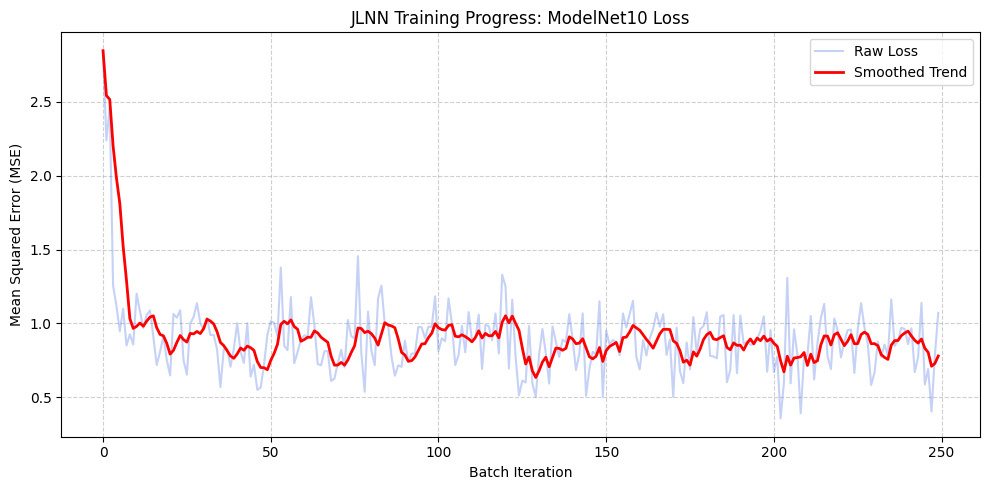

In [13]:
plot_loss(history_loss)

In [14]:
def plot_training_results(losses, bces, uncs):
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Primary axis for Loss
    ax1.plot(losses, alpha=0.2, color='royalblue', label='Total Loss')
    # Smoothed BCE trend
    if len(bces) > 5:
        smooth_bce = [sum(bces[max(0, i-10):i+1]) / len(bces[max(0, i-10):i+1]) for i in range(len(bces))]
        ax1.plot(smooth_bce, color='red', linewidth=2, label='BCE Trend (Accuracy Indicator)')

    ax1.set_xlabel('Batch Iteration')
    ax1.set_ylabel('Loss / BCE', color='red')
    ax1.tick_params(axis='y', labelcolor='red')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Secondary axis for Uncertainty
    ax2 = ax1.twinx()
    if len(uncs) > 5:
        smooth_unc = [sum(uncs[max(0, i-10):i+1]) / len(uncs[max(0, i-10):i+1]) for i in range(len(uncs))]
        ax2.plot(smooth_unc, color='green', linestyle=':', label='Uncertainty Trend')

    ax2.set_ylabel('Uncertainty (U-L)', color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    plt.title('JLNN Training: PointNet Learning vs Logic Constraints')
    fig.tight_layout()
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.show()

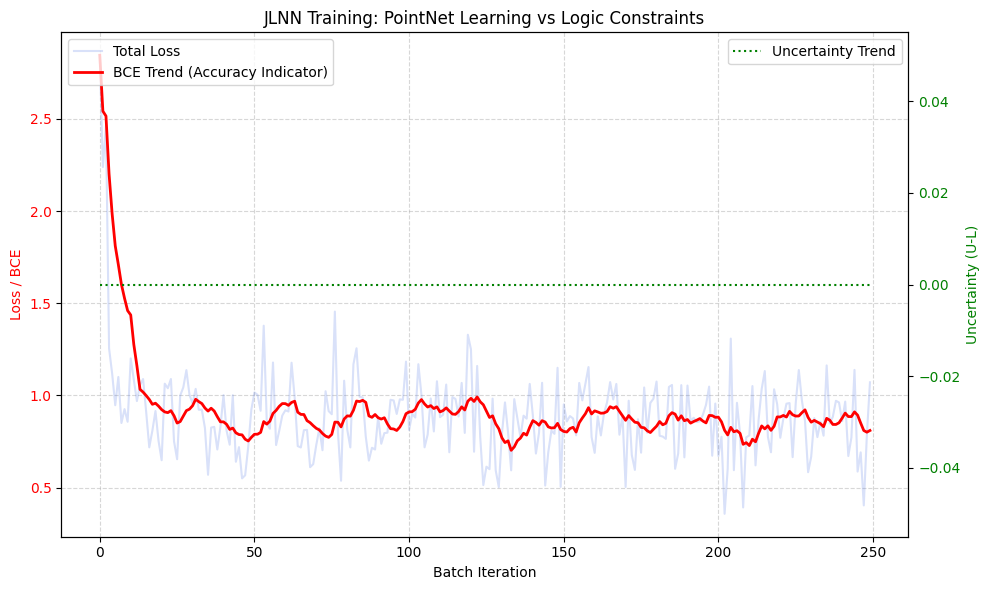

In [15]:
plot_training_results(history_loss, history_bce, history_unc)